In [ ]:
import sys
from pathlib import Path
from src.preprocessing.prepare_pt_from_tiff import collect_jobs, execute_parallel



tiff_root = Path("examples/simulations/tiff_files")
out_root  = Path("examples/simulations/pt_files")

# # Creating the pt files for the input image sequences
# jobs = collect_jobs(
#     tiff_root=tiff_root,
#     out_root=out_root,
#     subname= 'Noisy',                 # this must be the folder name under each PatternID_Training/
#     pt_foldername= "input",           # output folder inside pt_files/<SettingID_TrainingSet>/
#     pt_filename="input",             # will create <PID>_target_<SNR>.pt
#     input_glob="*_noisyvid_mct.tif",         # match files inside _SOFI_/
#     setting_filter=None,              # or ["01", "02"]
#     snr_filter=None,                  # or ["01", "02"]
#     li_thr=False,
# )

# print("Number of jobs found:", len(jobs))
# print("Example job:", jobs[0] if jobs else None)

# # Run conversion
# execute_parallel(
#     jobs=jobs,
#     max_workers=8,
#     framenum=100,     # how many frames to keep
#     start=0,
#     roix=(0, 0),
#     roiy=(0, 0),
#     li_thr=False,
# )


# # Option 1: Create pt files by mapping each input to corresponding sofi output

# jobs = collect_jobs(
#     tiff_root=tiff_root,
#     out_root=out_root,
#     subname='_SOFI_Results_fwhm2.7/*_100f__iter10_recon0_subseqlength100*',                 # this must be the folder name under each PatternID_Training/
#     pt_foldername="target",           # output folder inside pt_files/<SettingID_TrainingSet>/
#     pt_filename="target",             # will create <PID>_target_<SNR>.pt
#     input_glob="*_mctsofi2.tif",         # match files inside _SOFI_/
#     setting_filter=None,              # or ["01", "02"]
#     snr_filter=None,                  # or ["01", "02"]
#     li_thr=False,
# )

# print("Number of jobs found:", len(jobs))
# print("Example job:", jobs[0] if jobs else None)

# # Run conversion
# execute_parallel(
#     jobs=jobs,
#     max_workers=8,
#     framenum=1,     # how many frames to keep
#     start=0,
#     roix=(0, 0),
#     roiy=(0, 0),
#     li_thr=False,
# )

# # Option 2:  Create pt files by mapping each input to corresponding sofi_wbns output

# jobs = collect_jobs(
#     tiff_root=tiff_root,
#     out_root=out_root,
#     subname='WBNS_SOFI_Results_fwhm2.7/*_100f__iter10_recon0_subseqlength100*',                 # this must be the folder name under each PatternID_Training/
#     pt_foldername="target_wbns",           # output folder inside pt_files/<SettingID_TrainingSet>/
#     pt_filename="target",             # will create <PID>_target_<SNR>.pt
#     input_glob="*_mctsofi2.tif",         # match files inside _SOFI_/
#     setting_filter=None,              # or ["01", "02"]
#     snr_filter=None,                  # or ["01", "02"]
#     li_thr=False,
# )

# print("Number of jobs found:", len(jobs))
# print("Example job:", jobs[0] if jobs else None)

# # Run conversion
# execute_parallel(
#     jobs=jobs,
#     max_workers=8,
#     framenum=1,     # how many frames to keep
#     start=0,
#     roix=(0, 0),
#     roiy=(0, 0),
#     li_thr=False,
# )

# # Option 3:  Create pt files by mapping each input to corresponding sofi_wbns output and with Li-mask

# jobs = collect_jobs(
#     tiff_root=tiff_root,
#     out_root=out_root,
#     subname='WBNS_SOFI_Results_fwhm2.7/*_100f__iter10_recon0_subseqlength100*',                 # this must be the folder name under each PatternID_Training/
#     pt_foldername="target_wbns_li",           # output folder inside pt_files/<SettingID_TrainingSet>/
#     pt_filename="target",             # will create <PID>_target_<SNR>.pt
#     input_glob="*_mctsofi2.tif",         # match files inside _SOFI_/
#     setting_filter=None,              # or ["01", "02"]
#     snr_filter=None,                  # or ["01", "02"]
#     li_thr=True,
#     li_subname = 'WBNS_SOFI_Results_fwhm2.7/*_100f__iter10_recon0_subseqlength100*',
#     li_snr_prefix = "01_",
# )

# print("Number of jobs found:", len(jobs))
# print("Example job:", jobs[0] if jobs else None)

# # Run conversion
# execute_parallel(
#     jobs=jobs,
#     max_workers=8,
#     framenum=1,     # how many frames to keep
#     start=0,
#     roix=(0, 0),
#     roiy=(0, 0),
#     li_thr=True,
# )



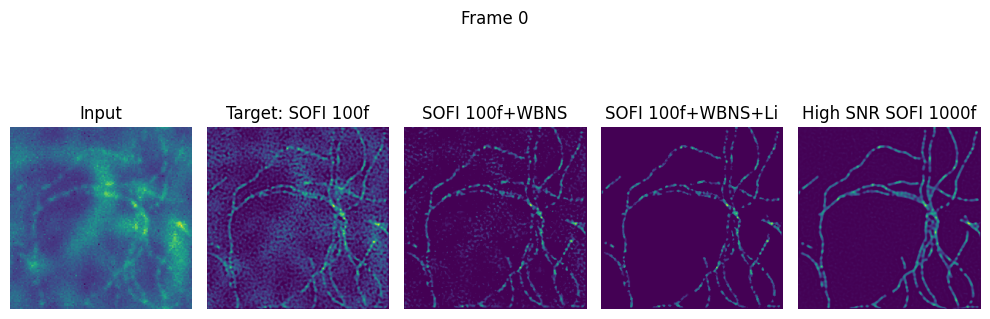

In [4]:
## Possible target options for the SNRID of the image with the lowest quality: *_04.tif

import torch
import matplotlib.pyplot as plt
from pathlib import Path


inp = Path("examples/simulations/pt_files/01_TrainingSet/input/01001_input_04.pt")
tgt = Path("examples/simulations/pt_files/01_TrainingSet/target/01001_target_04.pt")
tgt_wbns = Path("examples/simulations/pt_files/01_TrainingSet/target_wbns/01001_target_04.pt")
tgt_wbns_li = Path("examples/simulations/pt_files/01_TrainingSet/target_wbns_li/01001_target_04.pt")
tgt_hsnr = Path("examples/simulations/pt_files/01_TrainingSet/target/01001_target_01.pt")



x_in = torch.load(inp)
x_tg = torch.load(tgt)
x_tg_wbns = torch.load(tgt_wbns)
x_tg_wbns_li = torch.load(tgt_wbns_li)
x_tg_hsnr = torch.load(tgt_hsnr)

f = 0  # frame index

plt.figure(figsize=(10,4))
plt.subplot(1,5,1)
plt.imshow(x_in[f].cpu().numpy())
plt.title("Input")
plt.axis("off")

plt.subplot(1,5,2)
plt.imshow(x_tg[f].cpu().numpy())
plt.title("Target: SOFI 100f")
plt.axis("off")

plt.subplot(1,5,3)
plt.imshow(x_tg_wbns[f].cpu().numpy())
plt.title("SOFI 100f+WBNS")
plt.axis("off")

plt.subplot(1,5,4)
plt.imshow(x_tg_wbns_li[f].cpu().numpy())
plt.title("SOFI 100f+WBNS+Li")
plt.axis("off")

plt.subplot(1,5,5)
plt.imshow(x_tg_hsnr[f].cpu().numpy())
plt.title("High SNR SOFI 1000f")
plt.axis("off")

plt.suptitle(f"Frame {f}")
plt.tight_layout()
plt.show()
